<a href="https://colab.research.google.com/github/rachakondasaivarshini/AIML-EXPS/blob/main/AIML_EXP_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

KNN Accuracy for Different k Values
-----------------------------------
k = 1 --> Accuracy = 0.71
k = 3 --> Accuracy = 0.76
k = 5 --> Accuracy = 0.78
k = 7 --> Accuracy = 0.80


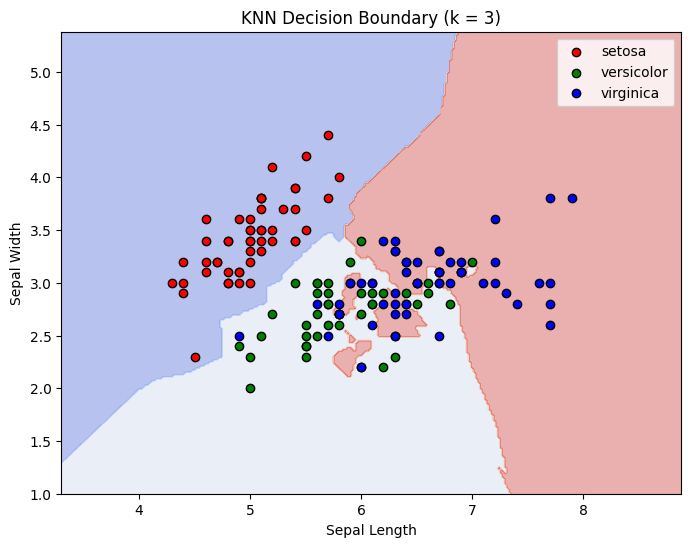

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Step 1: Load the Iris dataset
iris = datasets.load_iris()

# Use only first two features for 2D visualization
X = iris.data[:, :2]
y = iris.target

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Step 2: Train KNN with different k values
k_values = [1, 3, 5, 7]

print("KNN Accuracy for Different k Values")
print("-----------------------------------")

for k in k_values:
    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric='euclidean'
    )

    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print(f"k = {k} --> Accuracy = {acc:.2f}")

# Step 3: Visualize Decision Boundaries for k = 3
knn = KNeighborsClassifier(
    n_neighbors=3,
    metric='euclidean'
)

knn.fit(X_train, y_train)

h = 0.02

x_min = X[:, 0].min() - 1
x_max = X[:, 0].max() + 1

y_min = X[:, 1].min() - 1
y_max = X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))

plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.coolwarm)

colors = ['red', 'green', 'blue']

for i, color in zip(range(3), colors):
    idx = np.where(y == i)
    plt.scatter(
        X[idx, 0],
        X[idx, 1],
        c=color,
        label=iris.target_names[i],
        edgecolor='black'
    )

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("KNN Decision Boundary (k = 3)")
plt.legend()
plt.show()

Decision Tree Accuracy = 1.0


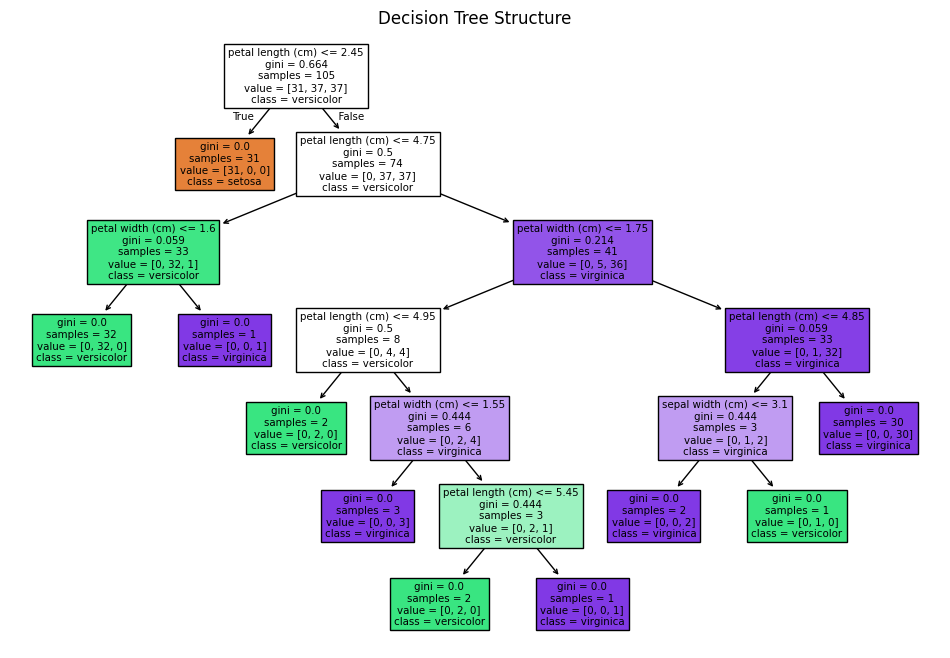


Pruning Results
----------------
Max Depth = 2, Accuracy = 0.98, Tree Size = 5
Max Depth = 3, Accuracy = 1.00, Tree Size = 9
Max Depth = 4, Accuracy = 1.00, Tree Size = 13


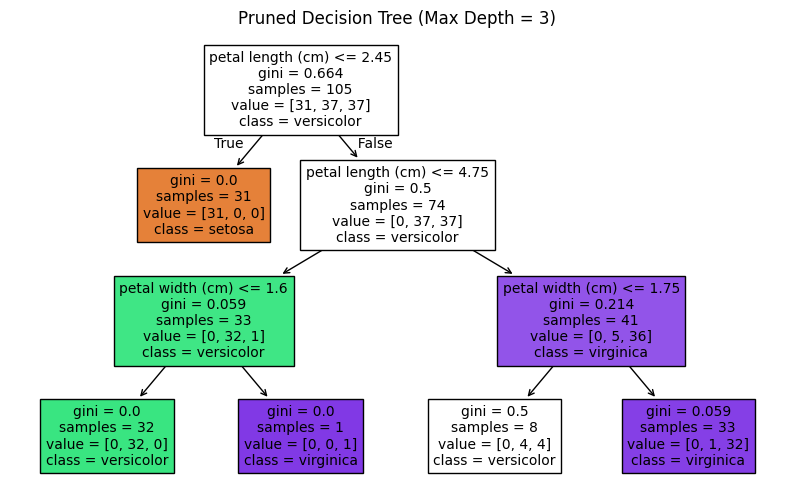

In [2]:
# Import required libraries
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

# Step 1: Load Iris Dataset
iris = datasets.load_iris()

X = iris.data
y = iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Step 2: Train Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

# Predict test data
y_pred = dt.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Decision Tree Accuracy =", round(accuracy, 2))

# Step 3: Visualize Tree Structure
plt.figure(figsize=(12, 8))

plot_tree(
    dt,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

plt.title("Decision Tree Structure")
plt.show()

# Step 4: Pruning using max_depth
depth_values = [2, 3, 4]

print("\nPruning Results")
print("----------------")

for depth in depth_values:

    pruned_tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    pruned_tree.fit(X_train, y_train)

    y_pred = pruned_tree.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print(
        f"Max Depth = {depth}, "
        f"Accuracy = {acc:.2f}, "
        f"Tree Size = {pruned_tree.tree_.node_count}"
    )

# Visualize Pruned Tree (Depth = 3)
pruned_tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

pruned_tree.fit(X_train, y_train)

plt.figure(figsize=(10, 6))

plot_tree(
    pruned_tree,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

plt.title("Pruned Decision Tree (Max Depth = 3)")
plt.show()